#Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

##Load and Show Image

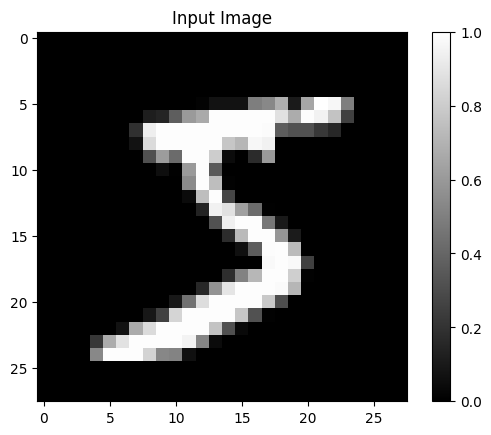

Shape: (28, 28)


In [ ]:
(train_images, train_labels), _ = mnist.load_data()

image = train_images[0] / 255.0

plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.colorbar()
plt.show()

print("Shape:", image.shape)

##Define Convolution (FROM SCRATCH)

In [ ]:
def convolve(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]

    output = np.zeros((h-k+1, w-k+1))

    for i in range(h-k+1):
        for j in range(w-k+1):
            patch = image[i:i+k, j:j+k]
            output[i,j] = np.sum(patch * kernel)

    return output

##First Convolution Layer

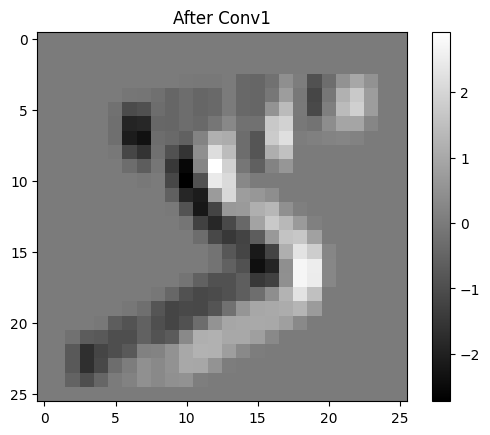

Shape after Conv1: (26, 26)


In [ ]:
kernel1 = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

conv1 = convolve(image, kernel1)

plt.imshow(conv1, cmap='gray')
plt.title("After Conv1")
plt.colorbar()
plt.show()

print("Shape after Conv1:", conv1.shape)

##ReLU

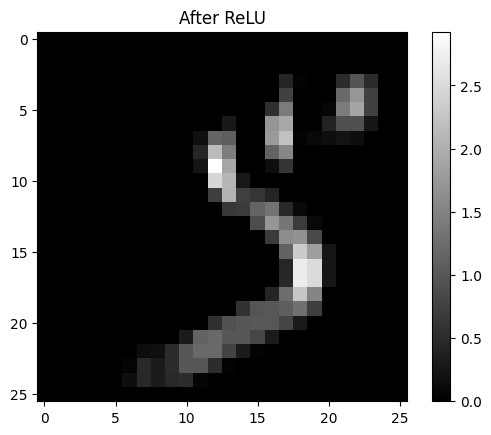

In [ ]:
relu1 = np.maximum(0, conv1)

plt.imshow(relu1, cmap='gray')
plt.title("After ReLU")
plt.colorbar()
plt.show()

##Max Pooling

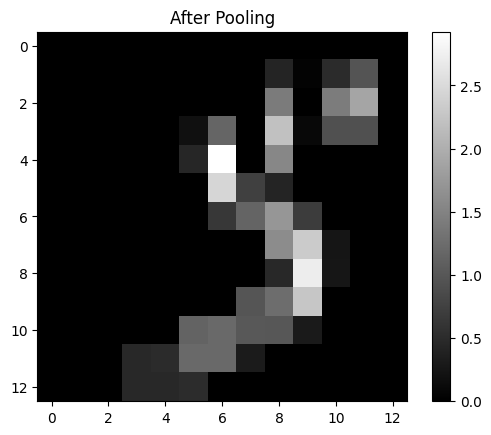

Shape after pooling: (13, 13)


In [ ]:
def max_pool(image):
    h, w = image.shape
    output = np.zeros((h//2, w//2))

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            patch = image[i:i+2, j:j+2]
            output[i//2, j//2] = np.max(patch)

    return output

pool1 = max_pool(relu1)

plt.imshow(pool1, cmap='gray')
plt.title("After Pooling")
plt.colorbar()
plt.show()

print("Shape after pooling:", pool1.shape)

##Second Convolution

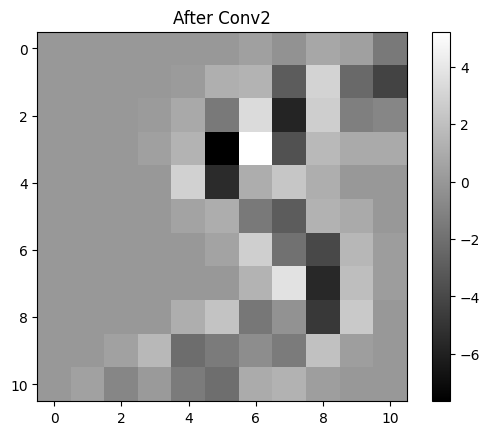

Shape after Conv2: (11, 11)


In [ ]:
kernel2 = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

conv2 = convolve(pool1, kernel2)

plt.imshow(conv2, cmap='gray')
plt.title("After Conv2")
plt.colorbar()
plt.show()

print("Shape after Conv2:", conv2.shape)

##Upsampling

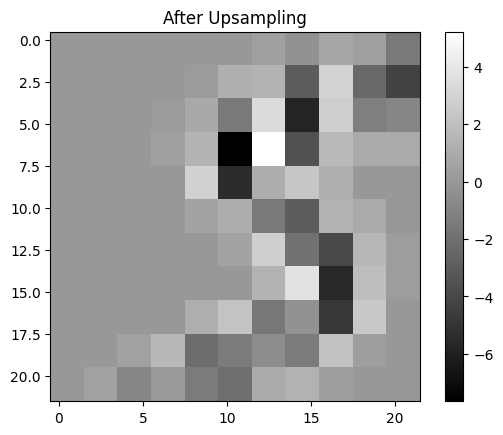

Shape after Upsampling: (22, 22)


In [ ]:
def upsample(image, scale=2):
    h, w = image.shape
    output = np.zeros((h*scale, w*scale))

    for i in range(h):
        for j in range(w):
            output[i*scale:(i+1)*scale, j*scale:(j+1)*scale] = image[i,j]

    return output

up1 = upsample(conv2)

plt.imshow(up1, cmap='gray')
plt.title("After Upsampling")
plt.colorbar()
plt.show()

print("Shape after Upsampling:", up1.shape)

##Resize to Original Size

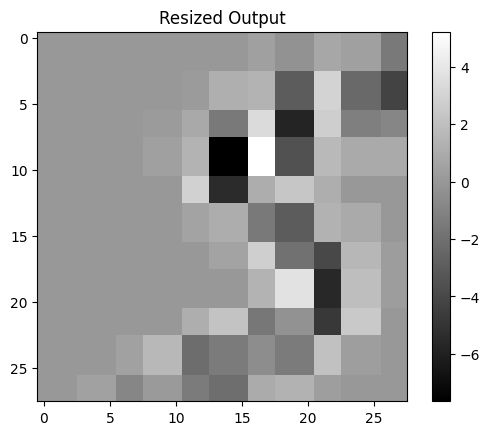

In [ ]:
# Resize manually to 28×28
final_output = np.zeros_like(image)

h, w = up1.shape

for i in range(28):
    for j in range(28):
        final_output[i,j] = up1[i * h // 28, j * w // 28]

plt.imshow(final_output, cmap='gray')
plt.title("Resized Output")
plt.colorbar()
plt.show()

##Convert to Segmentation Mask

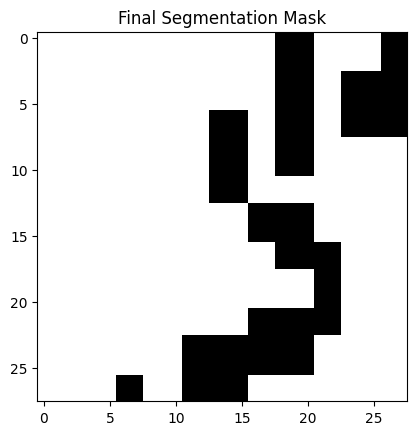

In [ ]:
# Thresholding for segmentation
mask = final_output > np.mean(final_output)

plt.imshow(mask, cmap='gray')
plt.title("Final Segmentation Mask")
plt.show()

#With Complete Training
#Load Data + Create Segmentation Labels

In [ ]:
(train_images, _), _ = mnist.load_data()

# Normalize
train_images = train_images / 255.0

# Create masks (segmentation labels)
train_masks = (train_images > 0).astype(float)

# Use small dataset for speed
train_images = train_images[:200]
train_masks = train_masks[:200]

print("Data shape:", train_images.shape)

Data shape: (200, 28, 28)


##Convolution Layer (Trainable)

In [ ]:
class Conv:
    def __init__(self, num_filters):
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def forward(self, image):
        self.last_input = image
        h, w = image.shape
        self.output = np.zeros((h-2, w-2, len(self.filters)))

        for f in range(len(self.filters)):
            for i in range(h-2):
                for j in range(w-2):
                    patch = image[i:i+3, j:j+3]
                    self.output[i,j,f] = np.sum(patch * self.filters[f])

        return self.output

    def backward(self, dL_dout, lr):
        dL_dfilters = np.zeros(self.filters.shape)

        for f in range(len(self.filters)):
            for i in range(dL_dout.shape[0]):
                for j in range(dL_dout.shape[1]):
                    patch = self.last_input[i:i+3, j:j+3]
                    dL_dfilters[f] += dL_dout[i,j,f] * patch

        self.filters -= lr * dL_dfilters

##ReLU

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

##Upsampling

In [ ]:
def upsample(image, target_h, target_w):
    h, w, f = image.shape
    out = np.zeros((target_h, target_w, f))

    for i in range(target_h):
        for j in range(target_w):
            # Safe index mapping
            src_i = min(int(i * h / target_h), h - 1)
            src_j = min(int(j * w / target_w), w - 1)

            out[i, j] = image[src_i, src_j]

    return out

##Final Pixel Classifier

In [ ]:
class PixelClassifier:
    def __init__(self, in_channels):
        self.weights = np.random.randn(in_channels) / in_channels
        self.bias = 0

    def forward(self, x):
        self.last_input = x  # shape (C,)
        return np.dot(x, self.weights) + self.bias

    def backward(self, dL_dout, lr):
        # Ensure scalar gradient
        dL_dout = float(dL_dout)

        # Gradient w.r.t weights
        dL_dw = self.last_input * dL_dout  # (C,)

        # Gradient w.r.t input (VERY IMPORTANT)
        dL_dinput = self.weights * dL_dout  # (C,)

        # Update weights
        self.weights -= lr * dL_dw
        self.bias -= lr * dL_dout

        return dL_dinput

##Loss (Pixel-wise Binary Cross Entropy)

In [ ]:
def sigmoid(x):
    # Numerical stability
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))


def loss_fn(pred, target):
    # Clip predictions to avoid log(0)
    pred = np.clip(pred, 1e-7, 1 - 1e-7)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred))


def loss_deriv(pred, target):
    # Correct derivative when using sigmoid + BCE together
    return (pred - target)

##Initialize Model

In [ ]:
conv = Conv(4)
classifier = PixelClassifier(4)

##Training Step

In [ ]:
def train_step(image, mask, lr=0.01):

    # ---------------- FORWARD ----------------
    out = conv.forward(image)          # (26,26,4)
    out_relu = relu(out)

    # Correct upsampling
    up = upsample(out_relu, 28, 28)    # (28,28,4)

    h, w, c = up.shape
    preds = np.zeros((h, w))

    # Pixel-wise classification
    for i in range(h):
        for j in range(w):
            preds[i,j] = sigmoid(classifier.forward(up[i,j]))

    # Ensure mask is same size
    mask_resized = mask   # already (28,28)

    # Loss
    loss = np.mean(loss_fn(preds, mask_resized))

    # ---------------- BACKWARD ----------------
    grad = loss_deriv(preds, mask_resized)   # (28,28)

    grad_classifier = np.zeros_like(up)      # (28,28,4)

    # Backprop through classifier
    for i in range(h):
        for j in range(w):
            grad_classifier[i,j] = classifier.backward(grad[i,j], lr)

    #  CORRECT gradient resizing (NOT slicing)
    grad_conv = np.zeros_like(out)  # (26,26,4)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            src_i = int(i * h / out.shape[0])
            src_j = int(j * w / out.shape[1])
            grad_conv[i,j] = grad_classifier[src_i, src_j]

    # Apply ReLU gradient
    grad_conv = grad_conv * relu_deriv(out)

    # Backprop into conv
    conv.backward(grad_conv, lr)

    return loss

##Training Loop

In [ ]:
for epoch in range(3):
    total_loss = 0

    # Shuffle data each epoch
    indices = np.random.permutation(len(train_images))

    for count, i in enumerate(indices):
        loss = train_step(train_images[i], train_masks[i])
        total_loss += loss

        # Print progress every 20 steps
        if count % 20 == 0:
            print(f"Epoch {epoch+1} | Step {count} | Loss: {loss:.4f}")

        # Safety check
        if np.isnan(loss):
            print("Loss became NaN — stopping training")
            break

    avg_loss = total_loss / len(train_images)
    print(f"\nEpoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f}\n")

Epoch 1 | Step 0 | Loss: 0.6891
Epoch 1 | Step 20 | Loss: 0.1321
Epoch 1 | Step 40 | Loss: 0.1749
Epoch 1 | Step 60 | Loss: 0.1993
Epoch 1 | Step 80 | Loss: 0.0538
Epoch 1 | Step 100 | Loss: 0.1174
Epoch 1 | Step 120 | Loss: 0.0800
Epoch 1 | Step 140 | Loss: 0.1733
Epoch 1 | Step 160 | Loss: 0.0674
Epoch 1 | Step 180 | Loss: 0.1817

Epoch 1 Completed | Avg Loss: 0.1424

Epoch 2 | Step 0 | Loss: 0.0949
Epoch 2 | Step 20 | Loss: 0.1994
Epoch 2 | Step 40 | Loss: 0.1709
Epoch 2 | Step 60 | Loss: 0.1936
Epoch 2 | Step 80 | Loss: 0.1469
Epoch 2 | Step 100 | Loss: 0.1679
Epoch 2 | Step 120 | Loss: 0.0785
Epoch 2 | Step 140 | Loss: 0.1223
Epoch 2 | Step 160 | Loss: 0.1575
Epoch 2 | Step 180 | Loss: 0.0955

Epoch 2 Completed | Avg Loss: 0.1357

Epoch 3 | Step 0 | Loss: 0.1891
Epoch 3 | Step 20 | Loss: 0.0280
Epoch 3 | Step 40 | Loss: 0.1343
Epoch 3 | Step 60 | Loss: 0.1490
Epoch 3 | Step 80 | Loss: 0.1161
Epoch 3 | Step 100 | Loss: 0.1058
Epoch 3 | Step 120 | Loss: 0.0897
Epoch 3 | Step 140 | L

##Test & Visualize

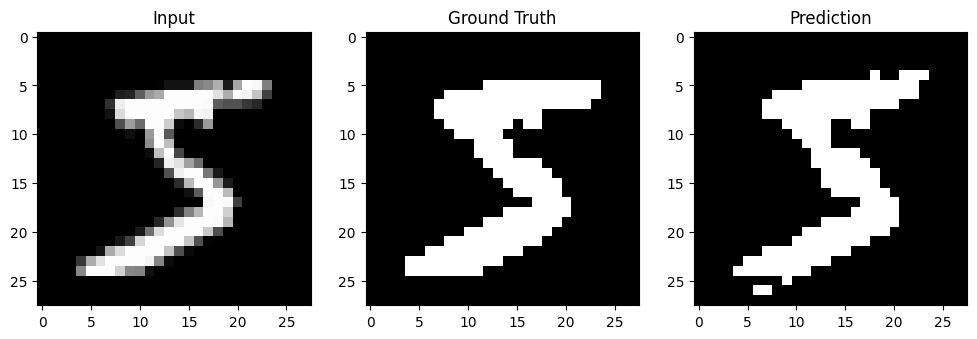

In [ ]:
test_img = train_images[0]

out = conv.forward(test_img)
out = relu(out)
up = upsample(out, 28, 28)

h,w,c = up.shape
pred = np.zeros((h,w))

for i in range(h):
    for j in range(w):
        pred[i,j] = sigmoid(classifier.forward(up[i,j]))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(test_img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(train_masks[0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred > 0.5, cmap='gray')

plt.show()

#With Library
##Install & Import

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

##Load Dataset (MNIST → Segmentation)

In [ ]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Create masks (digit vs background)
y_train = (x_train > 0).astype(np.float32)
y_test = (x_test > 0).astype(np.float32)

# Add channel dimension
x_train = x_train[..., np.newaxis]
y_train = y_train[..., np.newaxis]

x_test = x_test[..., np.newaxis]
y_test = y_test[..., np.newaxis]

print("Input shape:", x_train.shape)

Input shape: (60000, 28, 28, 1)


##Build FCN Model

In [ ]:
inputs = keras.Input(shape=(28, 28, 1))

# Encoder
x = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = keras.layers.MaxPooling2D()(x)

# Bottleneck
x = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

# Decoder (Upsampling)
x = keras.layers.UpSampling2D()(x)
x = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)

x = keras.layers.UpSampling2D()(x)
x = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(x)

# Output layer (pixel-wise)
outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

 Non-trainable params: 0 (0.00 B)

##Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##Train Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 149s 86ms/step - accuracy: 0.9779 - loss: 0.0538 - val_accuracy: 0.9871 - val_loss: 0.0316
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 157s 93ms/step - accuracy: 0.9904 - loss: 0.0245 - val_accuracy: 0.9921 - val_loss: 0.0203
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 156s 92ms/step - accuracy: 0.9934 - loss: 0.0173 - val_accuracy: 0.9943 - val_loss: 0.0152


##Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step


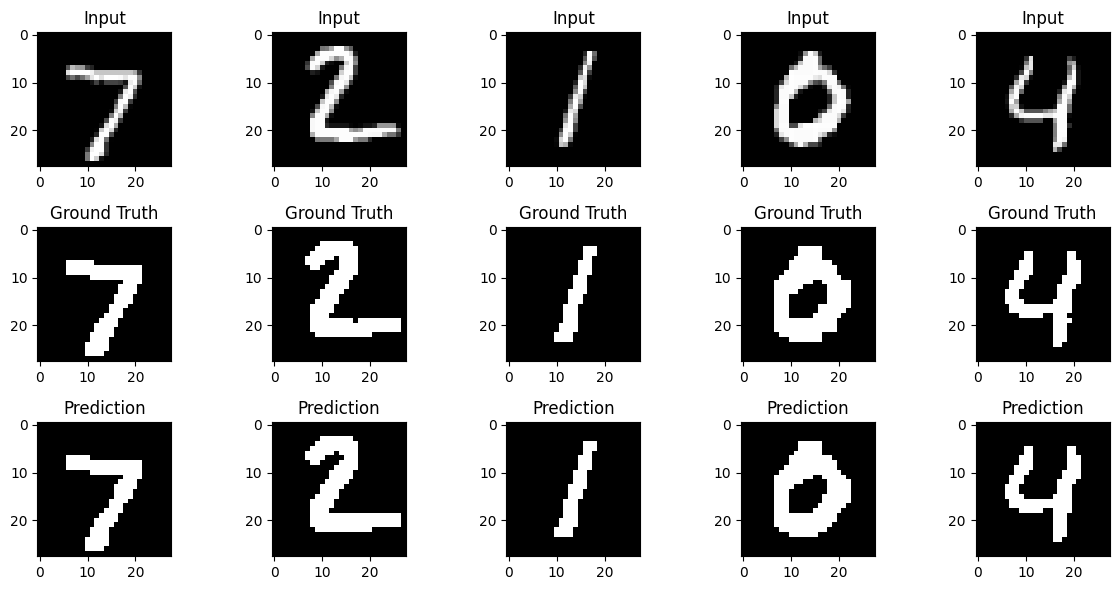

In [ ]:
preds = model.predict(x_test[:5])

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Input")

    plt.subplot(3,5,i+6)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(3,5,i+11)
    plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
    plt.title("Prediction")

plt.tight_layout()
plt.show()